In [1]:
import json
import pickle
from pathlib import Path
from collections import defaultdict, Counter

import pandas as pd
import numpy as np
import networkx as nx
from sklearn.feature_extraction.text import TfidfVectorizer

In [2]:

# Settings 
INPUT = "phase4_pca_clusters.json"            #  Phase 4 output
GRAPH_OUT = "phase5_taxonomy_graph.gpickle"   # saved via pickle (version-agnostic)
GRAPH_JSON_OUT = "phase5_taxonomy_graph.json" # node-link JSON (web-friendly)
TREE_JSON_OUT = "phase5_taxonomy_tree.json"   # nested L1->L2->L3 tree with clusters
CLUSTER_SUMMARY_OUT = "phase5_cluster_summary.csv"

INCLUDE_LEVEL4 = True                      # attach Level4/Product leaves for context
COLLAPSE_LEVEL4 = True                     # collapse many leaves into a "+N products" node
MAX_LEAVES_PER_CLUSTER = 15                # threshold for collapsing
# Labeling controls
N_TERMS_PER_CLUSTER = 5                    # TF-IDF terms per cluster label
EXCLUDE_BRANDS = True                      # drop brand tokens from labels (set False to allow)
NGRAMS = (1, 2)                            # 1–2 grams read well
MIN_DF = 3                                 # ignore very rare terms in TF-IDF
MAX_DF = 0.7                               # ignore very common terms in TF-IDF
MERGE_TFIDF_AND_KEYWORDS = True            # if True, labels combine TF-IDF + combined_keywords

In [3]:
# Ensure output folder exists (if you pass paths with folders)
for p in [GRAPH_OUT, GRAPH_JSON_OUT, TREE_JSON_OUT, CLUSTER_SUMMARY_OUT]:
    Path(p).parent.mkdir(parents=True, exist_ok=True)

In [4]:
# Load clustered data (drop noise)
df = pd.read_json(INPUT, lines=True)
df = df[df["HDBSCAN_Cluster"] >= 0].reset_index(drop=True)


In [5]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 379735 entries, 0 to 379734
Data columns (total 22 columns):
 #   Column                                      Non-Null Count   Dtype 
---  ------                                      --------------   ----- 
 0   Title                                       379735 non-null  object
 1   BrandInfo.BrandName                         379735 non-null  object
 2   ProductName                                 379735 non-null  object
 3   Category.Name.Value                         379735 non-null  object
 4   SummaryDescription.LongSummaryDescription   379735 non-null  object
 5   SummaryDescription.ShortSummaryDescription  379735 non-null  object
 6   Description.LongProductName                 379735 non-null  object
 7   Description.LongDesc                        379735 non-null  object
 8   pathlist_names                              379735 non-null  object
 9   Level1                                      379735 non-null  object
 10  Level2  

In [6]:
# Normalize fields we’ll use
for col in ["cleaned_text", "Level1", "Level2", "Level3", "Level4",
            "ProductName", "BrandInfo.BrandName", "combined_keywords"]:
    if col in df.columns:
        df[col] = df[col].fillna("")

# Level4 "None" as literal string → empty
if "Level4" in df.columns:
    df["Level4"] = df["Level4"].replace("None", "")

In [7]:
# Parse combined_keywords from Phase 2
def parse_kw(x):
    if x is None or (isinstance(x, float) and pd.isna(x)):
        return []
    if isinstance(x, list):
        return [str(t).strip() for t in x if t]
    if isinstance(x, str):
        s = x.strip()
        if not s:
            return []
        # Try JSON list
        try:
            maybe = json.loads(s)
            if isinstance(maybe, list):
                return [str(t).strip() for t in maybe if t]
        except Exception:
            pass
        # Fallback: comma-separated
        return [t.strip() for t in s.split(",") if t.strip()]
    return []

if "combined_keywords" in df.columns:
    df["combined_keywords"] = df["combined_keywords"].apply(parse_kw)
else:
    df["combined_keywords"] = [[] for _ in range(len(df))]


In [8]:
# Brand blacklist (optional)
brand_blacklist = set()
if EXCLUDE_BRANDS and "BrandInfo.BrandName" in df.columns:
    brand_blacklist = {b.strip().lower() for b in df["BrandInfo.BrandName"].unique() if b}


In [9]:
# TF-IDF cluster naming (over cleaned_text)
vectorizer = TfidfVectorizer(
    ngram_range=NGRAMS,
    min_df=MIN_DF,
    max_df=MAX_DF,
    stop_words="english",
)
X = vectorizer.fit_transform(df["cleaned_text"])
terms = np.array(vectorizer.get_feature_names_out())

In [10]:
terms

array(['00', '00 000', '00 cm', ..., 'zyxel zyassure', 'zyxel zywall',
       'zyxel zyx'], dtype=object)

In [11]:
cluster_names = {}
cluster_top_terms = {}
groups = df.groupby("HDBSCAN_Cluster").groups  # indices per cluster

for cid, idxs in groups.items():
    rows = X[list(idxs)]
    scores = rows.mean(axis=0).A1 if rows.shape[0] else np.zeros(X.shape[1])  # mean TF-IDF across docs
    order = np.argsort(scores)[::-1]

    selected = []
    for j in order:
        t = terms[j].strip()
        tl = t.lower()
        if EXCLUDE_BRANDS and tl in brand_blacklist:
            continue
        if tl.isdigit() or len(tl) <= 2:
            continue
        selected.append(t)
        if len(selected) >= N_TERMS_PER_CLUSTER:
            break

    if not selected:  # fallback if everything got filtered
        selected = list(terms[order[:N_TERMS_PER_CLUSTER]])

    cluster_top_terms[cid] = selected
    # initial TF-IDF-only label; may merge below
    cluster_names[cid] = ", ".join(selected)

In [12]:
# Aggregate combined_keywords per cluster
cluster_keywords = {}
for cid, sub in df.groupby("HDBSCAN_Cluster"):
    c = Counter()
    for kws in sub["combined_keywords"]:
        for w in kws:
            wl = w.lower()
            if EXCLUDE_BRANDS and wl in brand_blacklist:
                continue
            if len(wl) <= 2 or wl.isdigit():
                continue
            c[wl] += 1
    cluster_keywords[cid] = [w for w, _ in c.most_common(10)]  # top 10; adjust if you like


In [13]:
# Optionally merge TF-IDF + keywords for labels

def merge_label_terms(tfidf_terms, kw_terms, k=5):
    out, seen = [], set()
    for t in (tfidf_terms or []) + (kw_terms or []):
        if t not in seen:
            seen.add(t)
            out.append(t)
        if len(out) >= k:
            break
    return out

if MERGE_TFIDF_AND_KEYWORDS:
    for cid in list(groups.keys()):
        merged_terms = merge_label_terms(cluster_top_terms.get(cid, []),
                                         cluster_keywords.get(cid, []),
                                         k=N_TERMS_PER_CLUSTER)
        cluster_names[cid] = ", ".join(merged_terms)


In [14]:
# Build hierarchical graph
# Level1 → Level2 → Level3 → Cluster (+ optional Level4 leaves)
G = nx.DiGraph()

def add_node(key, label, ntype, **attrs):
    if key not in G:
        G.add_node(key, label=label, type=ntype, **attrs)

cluster_to_products = defaultdict(list)  # collect L4 leaves per cluster

for cid, sub in df.groupby("HDBSCAN_Cluster"):
    c_key = f"CLUSTER::{cid}"
    c_label = f"{cid}: {cluster_names.get(cid, '')}"
    add_node(
        c_key, c_label, "cluster",
        cluster_id=int(cid),
        size=int(len(sub)),                            # number of rows/docs in the cluster
        top_terms=cluster_top_terms.get(cid, []),      # TF-IDF top terms
        keywords=cluster_keywords.get(cid, []),        # aggregated combined_keywords
    )

    for _, row in sub.iterrows():
        l1 = row["Level1"].strip()
        l2 = row["Level2"].strip()
        l3 = row["Level3"].strip()

        k1 = f"L1::{l1}"
        k2 = f"L2::{l1}>{l2}"
        k3 = f"L3::{l1}>{l2}>{l3}"

        add_node(k1, l1, "level1")
        add_node(k2, l2, "level2")
        add_node(k3, l3, "level3")

        G.add_edge(k1, k2)
        G.add_edge(k2, k3)
        G.add_edge(k3, c_key)

        if INCLUDE_LEVEL4:
            leaf = row["Level4"].strip() if "Level4" in row and row["Level4"].strip() else row["ProductName"].strip()
            if leaf:
                cluster_to_products[cid].append(leaf)


In [15]:
cluster_to_products[cid]

['15-p203nv',
 '15-au008ns',
 '15-p251nq',
 '15-ab031tx',
 '15-ab216tx',
 '15-au503tx',
 '15-ab200ns',
 '15-p208ni',
 '15-au084tx',
 '15-p202nt',
 '15-p012tx',
 '15-p175na',
 '15-p107no',
 '15-p023tu',
 '15-p230nz',
 '15-ab247ng',
 '15-p221na',
 '15-p241tx',
 '15-ab535TX',
 '15-ab219ni',
 '15-ab007ur',
 '15-ab036ng',
 '15-ab006tx',
 '15-p250nz',
 '15-p040tu',
 '15-p282nr',
 '15-p206ng',
 '15-ab527tx',
 '15-p205ne',
 '15-p081tx',
 '15-p256ur',
 '15-ab218ni',
 '15-ab035ng',
 '15-p289nf',
 '15-p210tx',
 '15-p104nt',
 '15-p225tx',
 '15-p247tx',
 '15-p137nl',
 '15-ab232ng',
 '15-ab234ng',
 '15-ab203ng',
 '15-p151nr',
 '15-ab236nd',
 '15-au196tx',
 '15-p005ns',
 '15-ab208nt',
 '15-p288tx',
 '15-ab031ng',
 '15-p207nt',
 '15-p106nt',
 '15-p227ne',
 '15-ab252tu',
 '15-p205tx',
 '15-au019ur',
 '15-au117ur',
 '15-p261nb',
 '15-p246nl',
 '15-ab516tx',
 '15-p103no',
 '15-ab214nt',
 '15-au104nl',
 '15-p014si',
 '15-p289tx',
 '15-p260ur',
 '15-ab037ng',
 '15-au113ng',
 '15-au099tx',
 '15-p223ng',
 '1

In [16]:
# Attach Level4 leaves (collapse if many)
# ---------------------------
if INCLUDE_LEVEL4:
    for cid, products in cluster_to_products.items():
        c_key = f"CLUSTER::{cid}"
        if not products:
            continue

        # dedupe while preserving order
        seen, unique_products = set(), []
        for p in products:
            if p not in seen:
                seen.add(p)
                unique_products.append(p)

        if COLLAPSE_LEVEL4 and len(unique_products) > MAX_LEAVES_PER_CLUSTER:
            sum_key = f"LEAF::summary::{cid}"
            add_node(sum_key, f"+{len(unique_products)} products", "leaf", count=len(unique_products))
            G.add_edge(c_key, sum_key)
        else:
            for i, p in enumerate(unique_products[:MAX_LEAVES_PER_CLUSTER]):
                leaf_key = f"LEAF::{cid}::{i}"
                add_node(leaf_key, p[:100], "leaf")  # truncate long names to keep drawings tidy
                G.add_edge(c_key, leaf_key)


In [17]:
# 1) Binary graph via Python pickle (works on any NetworkX version)
import pickle
import json
from networkx.readwrite import json_graph
with open(GRAPH_OUT, "wb") as f:
    pickle.dump(G, f, protocol=pickle.HIGHEST_PROTOCOL)

# 2) Node-link JSON (great for web/Phase 7; contains top_terms & keywords)
with open(GRAPH_JSON_OUT, "w", encoding="utf-8") as f:
    json.dump(json_graph.node_link_data(G), f, ensure_ascii=False, indent=2)


/usr/local/lib/python3.11/dist-packages/networkx/readwrite/json_graph/node_link.py:142: FutureWarning: 
The default value will be `edges="edges" in NetworkX 3.6.

To make this warning go away, explicitly set the edges kwarg, e.g.:

  nx.node_link_data(G, edges="links") to preserve current behavior, or
  nx.node_link_data(G, edges="edges") for forward compatibility.
  warnings.warn(


In [18]:
# 3) Nested JSON: L1→L2→L3→clusters (with top_terms, keywords & sample products)
def nested_dict(): return defaultdict(nested_dict)
tree = nested_dict()

for cid, sub in df.groupby("HDBSCAN_Cluster"):
    meta = {
        "cluster_id": int(cid),
        "label": cluster_names.get(cid, ""),
        "size": int(len(sub)),
        "top_terms": cluster_top_terms.get(cid, []),
        "keywords": cluster_keywords.get(cid, []),   # include keywords
        "products": [],
    }
    if INCLUDE_LEVEL4:
        meta["products"] = (list(dict.fromkeys(cluster_to_products.get(cid, [])))
                            [:MAX_LEAVES_PER_CLUSTER])

    # mount once under the first seen L1→L2→L3
    r = sub.iloc[0]
    node = tree[r["Level1"]][r["Level2"]][r["Level3"]].setdefault("clusters", [])
    node.append(meta)

In [19]:
with open(TREE_JSON_OUT, "w", encoding="utf-8") as f:
    json.dump(tree, f, ensure_ascii=False, indent=2)


In [20]:
# 4) Flat CSV summary for quick QA
summary = (
    df.groupby("HDBSCAN_Cluster")
      .agg(size=("HDBSCAN_Cluster", "size"),
           sample_L1=("Level1", "first"),
           sample_L2=("Level2", "first"),
           sample_L3=("Level3", "first"))
      .reset_index()
)
summary["label"] = summary["HDBSCAN_Cluster"].map(cluster_names)
summary["top_terms"] = summary["HDBSCAN_Cluster"].map(lambda c: " | ".join(cluster_top_terms.get(c, [])))
summary["keywords"]  = summary["HDBSCAN_Cluster"].map(lambda c: " | ".join(cluster_keywords.get(c, [])))
summary.to_csv(CLUSTER_SUMMARY_OUT, index=False)

print(" Phase 5 complete (with keywords)")
print("Graph (pickle):", GRAPH_OUT)
print("Graph (node-link JSON):", GRAPH_JSON_OUT)
print("Tree JSON:", TREE_JSON_OUT)
print("Cluster summary CSV:", CLUSTER_SUMMARY_OUT)
print("Nodes:", G.number_of_nodes(), "Edges:", G.number_of_edges())
print("Sample labels:")
for cid in list(groups.keys())[:5]:
    print(f"  Cluster {cid}: {cluster_names[cid]}")

 Phase 5 complete (with keywords)
Graph (pickle): phase5_taxonomy_graph.gpickle
Graph (node-link JSON): phase5_taxonomy_graph.json
Tree JSON: phase5_taxonomy_tree.json
Cluster summary CSV: phase5_cluster_summary.csv
Nodes: 9727 Edges: 10201
Sample labels:
  Cluster 0: philip, extension philip, user manual, instruction video, philip extension
  Cluster 1: msi software, software msi, license msi, license, 25 license
  Cluster 2: uk 8hr, 5day category, 8hr 5day, 5day, 8hr
  Cluster 3: shredding, shredder, paper shredder, cross shredding, ps500
  Cluster 4: minimum, accounting software, pro enterprise, rittenregistratie, nedsoft rittenregistratie


In [21]:
import json

TREE_JSON_OUT = "phase5_taxonomy_tree.json"  # produced by Phase 5

with open(TREE_JSON_OUT, "r", encoding="utf-8") as f:
    tree = json.load(f)

def preview_tree(tree, max_l1=3, max_l2=3, max_l3=3, max_clusters=3, max_products=3):
    for i, (l1, L2) in enumerate(tree.items()):
        if i >= max_l1: break
        print(l1)
        for j, (l2, L3) in enumerate(L2.items()):
            if j >= max_l2: break
            print("  └─", l2)
            for k, (l3, payload) in enumerate(L3.items()):
                if k >= max_l3: break
                if "clusters" not in payload: 
                    continue
                print("      └─", l3)
                for m, c in enumerate(payload["clusters"][:max_clusters]):
                    print(f"          • Cluster {c['cluster_id']}: {c['label']} (size={c['size']})")
                    if c.get("top_terms"):
                        print("              top_terms:", ", ".join(c["top_terms"]))
                    if c.get("keywords"):
                        print("              keywords :", ", ".join(c["keywords"]))
                    if c.get("products"):
                        for p in c["products"][:max_products]:
                            print("              -", p)

# print a reasonably-sized slice; bump numbers to see more
preview_tree(tree, max_l1=999, max_l2=999, max_l3=999, max_clusters=5, max_products=5)


Computers & Electronics
  └─ Warranty & Support
      └─ Warranty & Support Extensions
          • Cluster 0: philip, extension philip, user manual, instruction video, philip extension (size=40)
              top_terms: philip, extension philip, user manual, instruction video, philip extension
              keywords : philip, support, year, product, extension, user, manual, warranty, ease, forum
              - 43BDL4050D/00-WARRANTY32
              - 55BDL3050Q/00-WARRANTY32
              - BDL5588XC/02-WARRANTY32
              - 65BDL3052T/00-WARRANTY32
              - 10BDL3051T/02-WARRANTY32
          • Cluster 2: uk 8hr, 5day category, 8hr 5day, 5day, 8hr (size=23)
              top_terms: uk 8hr, 5day category, 8hr 5day, 5day, 8hr
              keywords : business, service, day, support, year, category, diagnostics, monday, engineer, port
              - 3 Year Next Business Day Advance Replacement UK 8hr x 5day Category 4 Products
              - 3 Year Same Business Day Onsite 

/usr/local/lib/python3.11/dist-packages/networkx/readwrite/json_graph/node_link.py:287: FutureWarning: 
The default value will be changed to `edges="edges" in NetworkX 3.6.

To make this warning go away, explicitly set the edges kwarg, e.g.:

  nx.node_link_graph(data, edges="links") to preserve current behavior, or
  nx.node_link_graph(data, edges="edges") for forward compatibility.
  warnings.warn(


Loaded: 9727 nodes, 10201 edges


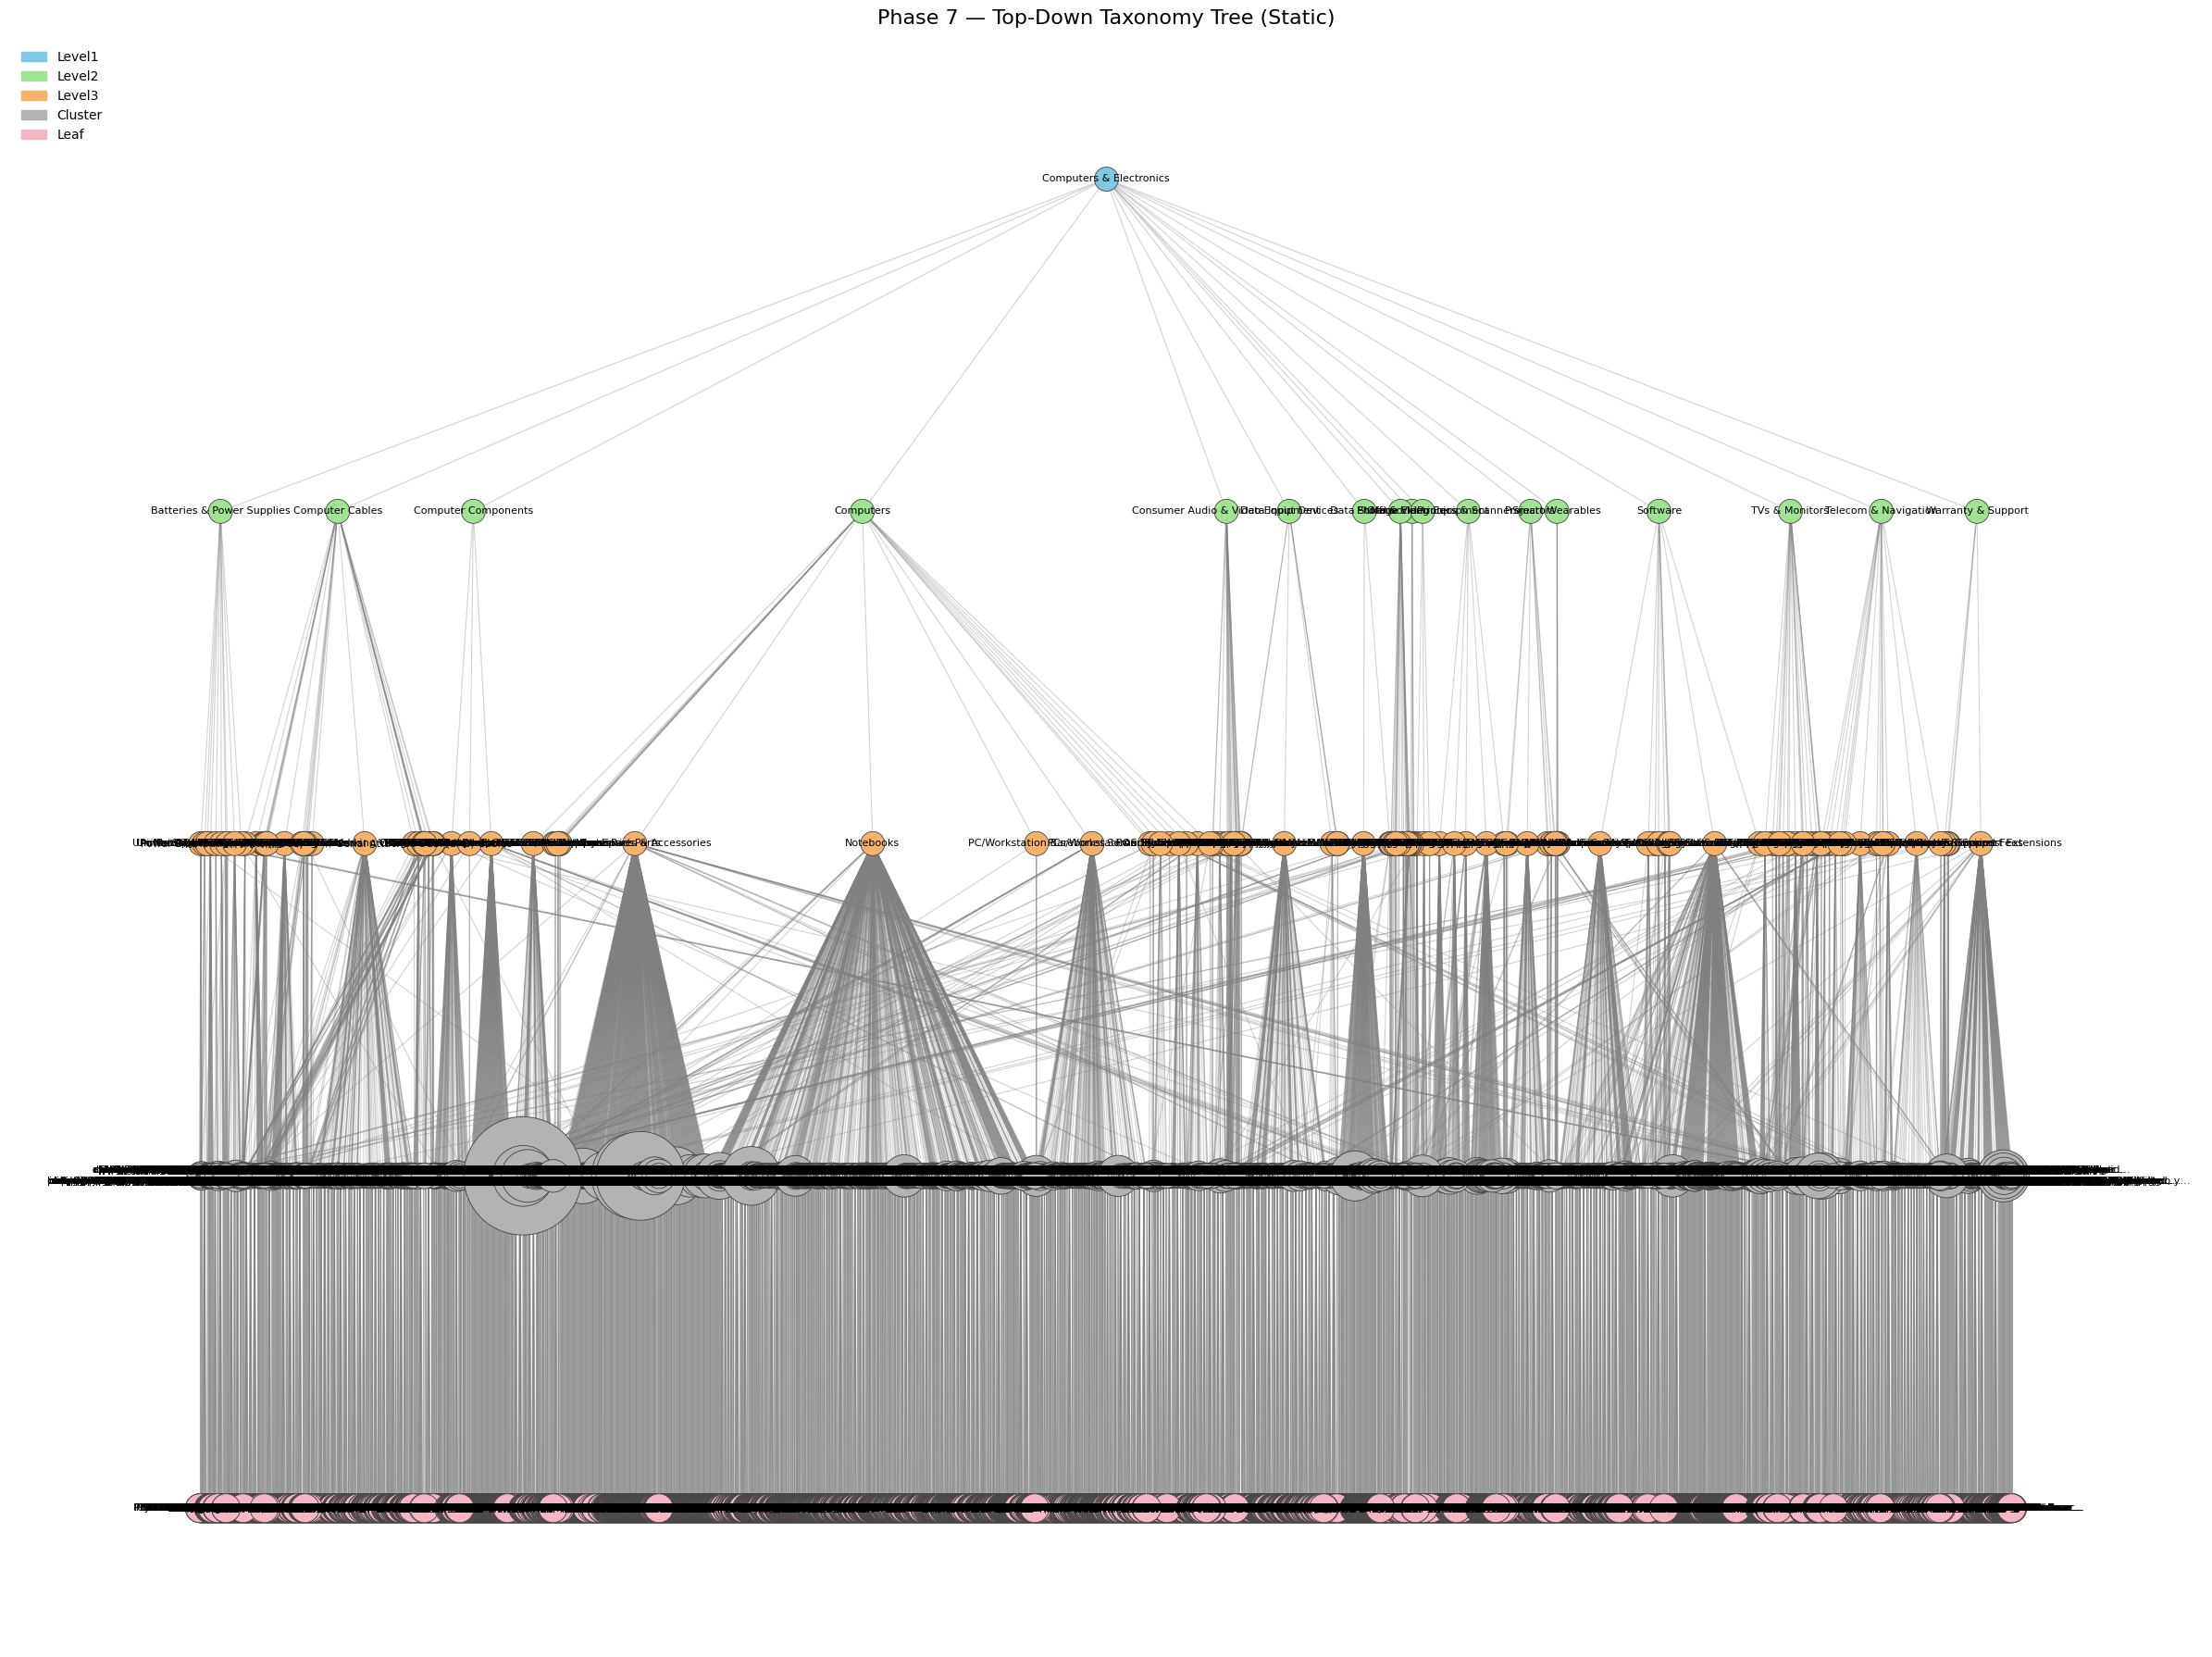

Saved: phase7_tree_static.png
Saved: phase7_tree_static.pdf


In [22]:

# Phase 7 (static): Top-Down Taxonomy Tree with Matplotlib

#  Loads: phase5_taxonomy_graph.json (from Phase 5)
# Top-down layered layout (no Graphviz)
#  Colors by node type; cluster size scales node size
# Optional: add top_terms/keywords under cluster labels
#  Saves PNG/PDF

import json
from collections import defaultdict
from pathlib import Path

import matplotlib.pyplot as plt
import matplotlib.patches as mpatches
import networkx as nx
from networkx.readwrite import json_graph

# Inputs / Toggles

GRAPH_JSON_IN = "phase5_taxonomy_graph.json"  # from Phase 5
PNG_OUT = "phase7_tree_static.png"
PDF_OUT = "phase7_tree_static.pdf"

FOCUS_L1 = None           # e.g. "Computers & Electronics" or None for all
INCLUDE_LEVEL4 = True     # include product leaves
SHOW_LABELS = True
MAX_LABEL = 40            # truncate main label
SHOW_TERMS = True         # add a 2nd line with terms for cluster nodes
TERMS_SOURCE = "both"     # "top_terms" | "keywords" | "both"
TERMS_K = 5               # how many terms to show
FIGSIZE = (24, 18)        # bigger = more readable
EDGE_ALPHA = 0.35

#  Load graph

with open(GRAPH_JSON_IN, "r", encoding="utf-8") as f:
    data = json.load(f)
G = json_graph.node_link_graph(data, directed=True, multigraph=False)
print("Loaded:", G.number_of_nodes(), "nodes,", G.number_of_edges(), "edges")


#  Optional filtering

if FOCUS_L1 is not None:
    roots = [n for n, d in G.nodes(data=True)
             if d.get("type") == "level1" and d.get("label") == FOCUS_L1]
    if not roots:
        raise ValueError(f"Level1 '{FOCUS_L1}' not found.")
    keep = set([roots[0]])
    keep.update(nx.descendants(G, roots[0]))
    G = G.subgraph(keep).copy()
    print(f"Focused on L1='{FOCUS_L1}':", G.number_of_nodes(), "nodes,", G.number_of_edges(), "edges")

if not INCLUDE_LEVEL4:
    leaves = [n for n, d in G.nodes(data=True) if d.get("type") == "leaf"]
    G.remove_nodes_from(leaves)
    print("Removed Level4 leaves:", len(leaves))


#  Build a tree-like layout (choose primary parent)

level_order = {"level1": 1, "level2": 2, "level3": 3, "cluster": 4, "leaf": 5}
def node_level(n):
    return level_order.get(G.nodes[n].get("type", "cluster"), 4)

# primary parent selection (closest to root)
parents = {n: [] for n in G.nodes()}
for u, v in G.edges():
    parents[v].append(u)
primary_parent = {}
for n in G.nodes():
    ps = parents[n]
    if not ps:
        primary_parent[n] = None
    else:
        ps.sort(key=lambda p: (node_level(p), G.nodes[p].get("label", "")))
        primary_parent[n] = ps[0]

children = defaultdict(list)
for n, p in primary_parent.items():
    if p is not None:
        children[p].append(n)

# roots
roots = [n for n in G.nodes()
         if primary_parent[n] is None and G.nodes[n].get("type") == "level1"]
if not roots:
    roots = [n for n in G.nodes() if primary_parent[n] is None]

# sort children/roots deterministically
for n in children:
    children[n].sort(key=lambda x: G.nodes[x].get("label", ""))
roots.sort(key=lambda x: G.nodes[x].get("label", ""))

# subtree widths so parents can sit centered above children
def subtree_width(n):
    if n not in children or len(children[n]) == 0:
        return 1
    return sum(subtree_width(c) for c in children[n])

xpos, ypos = {}, {}
Y_SPACING = 1.0

def place_subtree(n, x_left):
    w = subtree_width(n)
    x_center = x_left + w / 2.0
    xpos[n] = x_center
    ypos[n] = -node_level(n) * Y_SPACING
    cur = x_left
    for c in children.get(n, []):
        wc = subtree_width(c)
        place_subtree(c, cur)
        cur += wc

# layout each root in sequence with a gap
x_cursor = 0.0
GAP_BETWEEN_ROOTS = 2.0
for r in roots:
    w = subtree_width(r)
    place_subtree(r, x_cursor)
    x_cursor += w + GAP_BETWEEN_ROOTS

# any stragglers (rare)
for n in G.nodes():
    if n not in xpos:
        xpos[n] = x_cursor
        ypos[n] = -node_level(n) * Y_SPACING
        x_cursor += 1.0

pos = {n: (xpos[n], ypos[n]) for n in G.nodes()}


#  Styling

def node_color(d):
    t = d.get("type")
    return {
        "level1": "#7ec8e3",   # sky
        "level2": "#a0e493",   # green
        "level3": "#f6b26b",   # orange
        "cluster": "#b3b3b3",  # gray
        "leaf": "#f4b6c2",     # pink
    }.get(t, "#cccccc")

def node_size(d):
    base = 350
    if d.get("type") == "cluster":
        return max(base, base + 0.4 * d.get("size", 1))  # scale with cluster size
    if d.get("type") == "leaf":
        return 500
    return base

def cluster_label_text(raw):
    # "cid: terms" -> "terms"
    return raw.split(":", 1)[-1].strip() if ":" in (raw or "") else (raw or "")

def trunc(s, n=MAX_LABEL):
    s = s or ""
    return (s[:n-1] + "…") if len(s) > n else s

def second_line_terms(d):
    if not SHOW_TERMS or d.get("type") != "cluster":
        return ""
    top_terms = d.get("top_terms", [])
    keywords = d.get("keywords", [])
    if TERMS_SOURCE == "top_terms":
        bag = top_terms
    elif TERMS_SOURCE == "keywords":
        bag = keywords
    else:  # both
        # preserve order: top_terms first, then keywords
        seen, bag = set(), []
        for t in (top_terms or []) + (keywords or []):
            if t not in seen:
                seen.add(t)
                bag.append(t)
    if not bag:
        return ""
    return "\n" + trunc(", ".join(bag[:TERMS_K]), 60)

# Precompute visuals
sizes = [node_size(d) for _, d in G.nodes(data=True)]
colors = [node_color(d) for _, d in G.nodes(data=True)]
labels = {}
for n, d in G.nodes(data=True):
    raw = d.get("label", "") or str(n)
    main = cluster_label_text(raw) if d.get("type") == "cluster" else raw
    lbl = trunc(main, MAX_LABEL) + second_line_terms(d)
    # skip enormous strings on leaves
    if d.get("type") == "leaf":
        lbl = trunc(main, 30)
    labels[n] = lbl


#  Draw

plt.figure(figsize=FIGSIZE)

# Edges first
nx.draw_networkx_edges(
    G, pos,
    edge_color="gray",
    alpha=EDGE_ALPHA,
    arrows=False,
    width=0.8
)

# Draw nodes by type (for legend)
type_groups = defaultdict(list)
for n, d in G.nodes(data=True):
    type_groups[d.get("type", "other")].append(n)

for t, nodes in type_groups.items():
    nx.draw_networkx_nodes(
        G, pos,
        nodelist=nodes,
        node_size=[node_size(G.nodes[n]) for n in nodes],
        node_color=[node_color(G.nodes[n]) for n in nodes],
        linewidths=0.6,
        edgecolors="#444444",
        label=t.title()
    )

# Labels
if SHOW_LABELS:
    nx.draw_networkx_labels(
        G, pos,
        labels=labels,
        font_size=8,
        verticalalignment="center",
        horizontalalignment="center"
    )

# Legend
patches = [
    mpatches.Patch(color="#7ec8e3", label="Level1"),
    mpatches.Patch(color="#a0e493", label="Level2"),
    mpatches.Patch(color="#f6b26b", label="Level3"),
    mpatches.Patch(color="#b3b3b3", label="Cluster"),
    mpatches.Patch(color="#f4b6c2", label="Leaf"),
]
plt.legend(handles=patches, loc="upper left", frameon=False)

plt.title("Phase 7 — Top-Down Taxonomy Tree (Static)", fontsize=16, pad=12)
plt.axis("off")
plt.tight_layout()
plt.savefig(PNG_OUT, dpi=200)
plt.savefig(PDF_OUT)
plt.show()

print("Saved:", PNG_OUT)
print("Saved:", PDF_OUT)
